In [196]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
from PIL import Image
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import ConfusionMatrixDisplay

In [197]:
finalModel = tf.keras.models.load_model("final_model.keras")

In [198]:
finalModel.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 400)            │       314,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 300)            │       120,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 200)            │        60,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 627,012 (2.39 MB)

 Trainable params: 627,010 (2.39 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [199]:
fashionDataset = tf.keras.datasets.fashion_mnist.load_data()
(XTrain, yTrain), (XTest, yTest) = fashionDataset
XTest.shape, yTest.shape

((10000, 28, 28), (10000,))

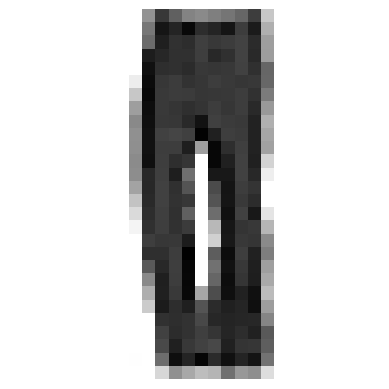

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 108, 198, 159,
        124, 117, 128, 138, 153, 194,  56,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 136, 234, 219,
        246, 210, 219, 234, 194, 228,  80,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 148, 224, 205,
        210, 192, 199, 195, 188, 212,  97,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 226, 216, 207,
        206, 193, 215, 206, 188, 213,  98,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 238, 209, 206,
        212, 198, 201, 198, 190, 207, 153,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  18, 244, 200, 195,
        204, 201, 194, 197, 201, 198, 152,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [200]:
def displayImage(img):
    plt.imshow(img, cmap="binary")
    plt.axis("off")
    plt.show()
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
"Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
displayImage(XTest[47])
XTest[47]

In [201]:
XTrain = XTrain.astype("float32") / 255.0
XTest = XTest.astype("float32") / 255.0

In [202]:
finalModel.evaluate(XTest, yTest)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 810us/step - loss: 0.5053 - sparse_categorical_accuracy: 0.9005


[0.5053330063819885, 0.9004999995231628]

In [203]:
yTestProba = finalModel.predict(XTest)
yTestIndex = yTestProba.argmax(axis=-1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 743us/step


In [204]:
class_names[0]

'T-shirt/top'

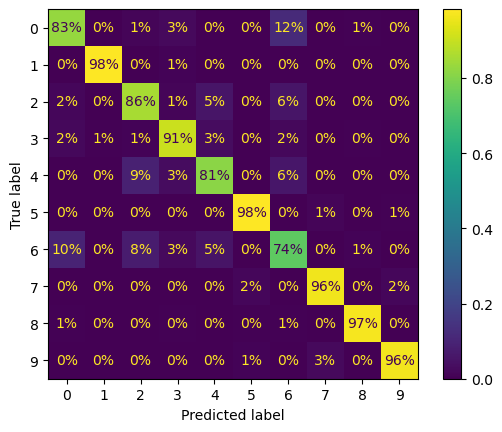

In [205]:
ConfusionMatrixDisplay.from_predictions(yTest, yTestIndex, normalize="true", values_format=".0%")
plt.show()

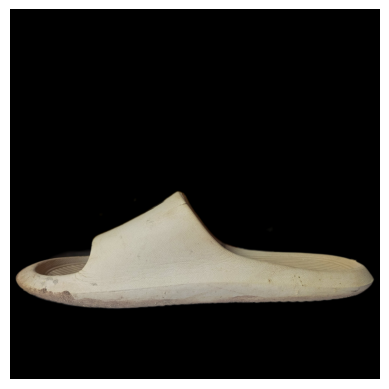

In [206]:
realWorld = Image.open("realWorld.jpg")
realWorldArray = np.asanyarray(realWorld)
displayImage(realWorldArray)

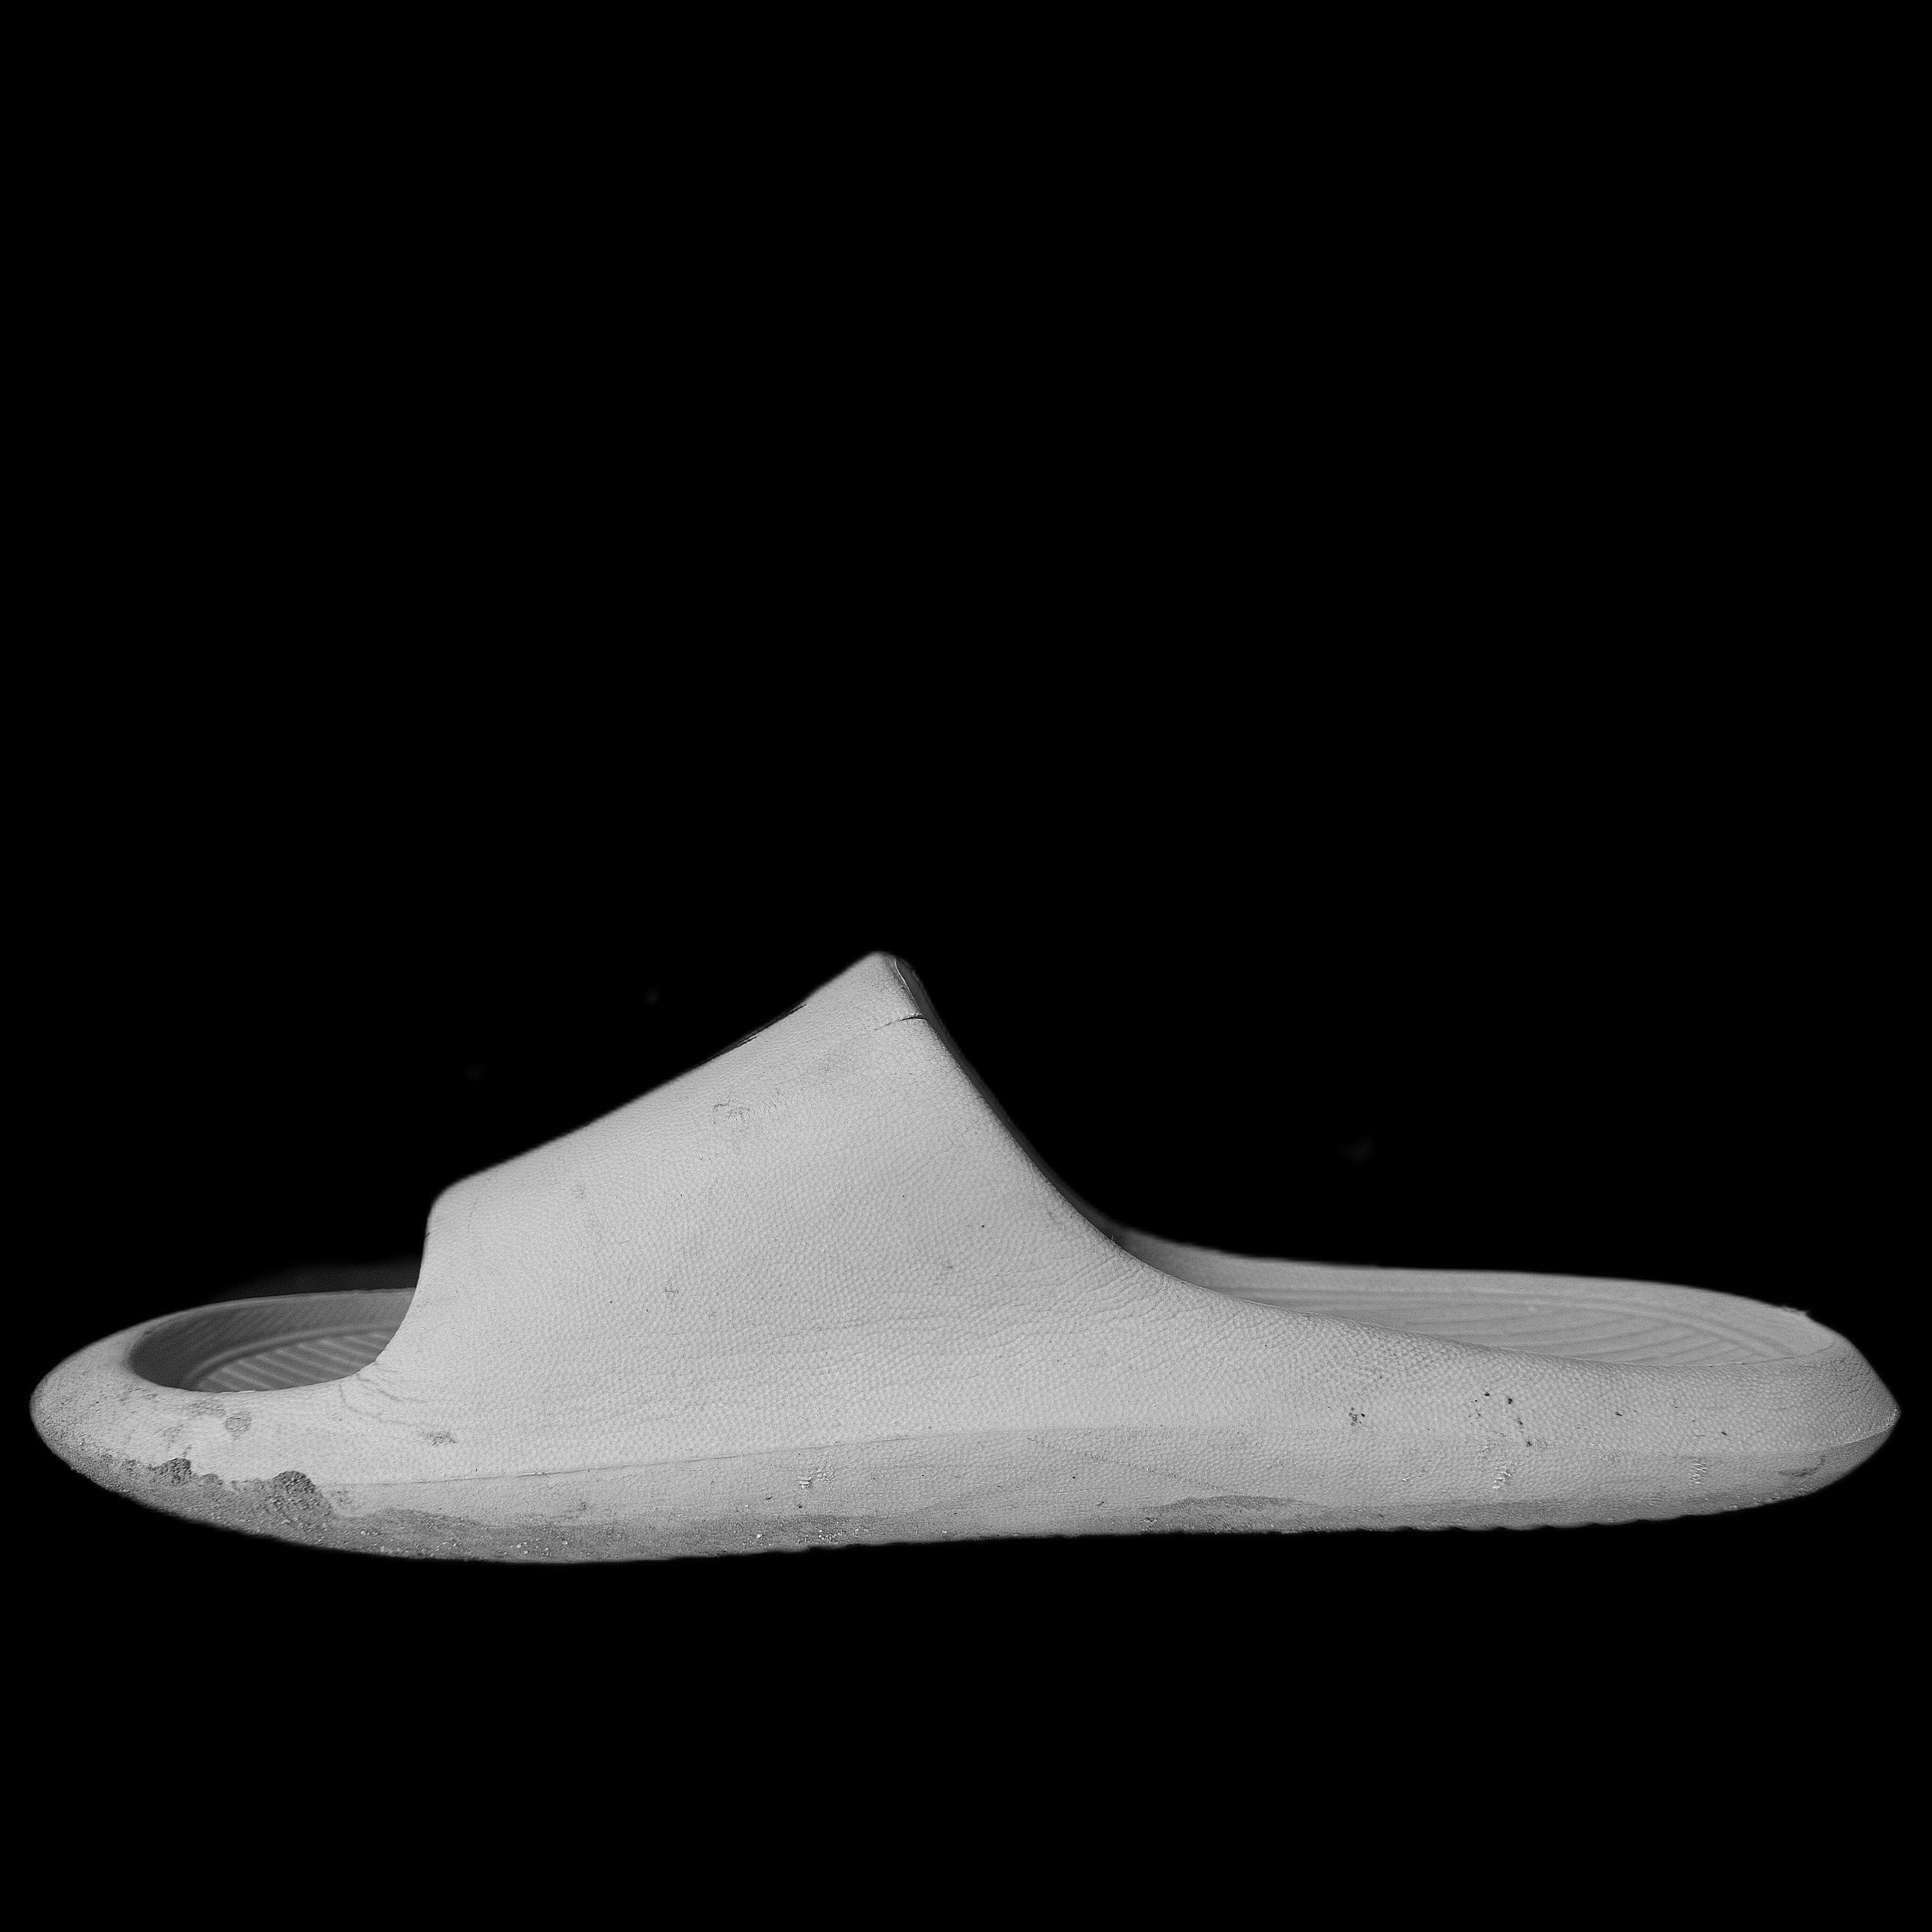

In [207]:
realWorld = realWorld.convert("L")
realWorld

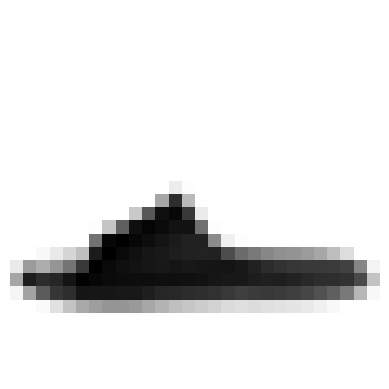

In [208]:
realWorld = realWorld.resize((28, 28))
realWorld = np.array(realWorld).astype("float32") / 255.0
displayImage(realWorld)

In [209]:
np.expand_dims(realWorld, axis=0).shape

(1, 28, 28)

In [210]:
realWorldPredictProba = finalModel.predict(np.expand_dims(realWorld, axis=0))
realWorldPredictProba.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.64, 0.  , 0.  , 0.36, 0.  ]],
      dtype=float32)

In [211]:
realWorldPredictIndex = realWorldPredictProba.argmax(axis=-1)
class_names[realWorldPredictIndex[0]]

'Sandal'

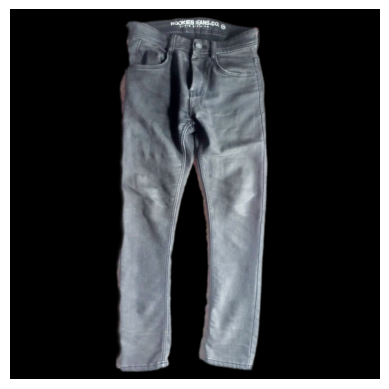

In [212]:
realWorldOne = Image.open("realWorldOne.jpg")
realWorldOneArray = np.asanyarray(realWorldOne)
displayImage(realWorldOneArray)

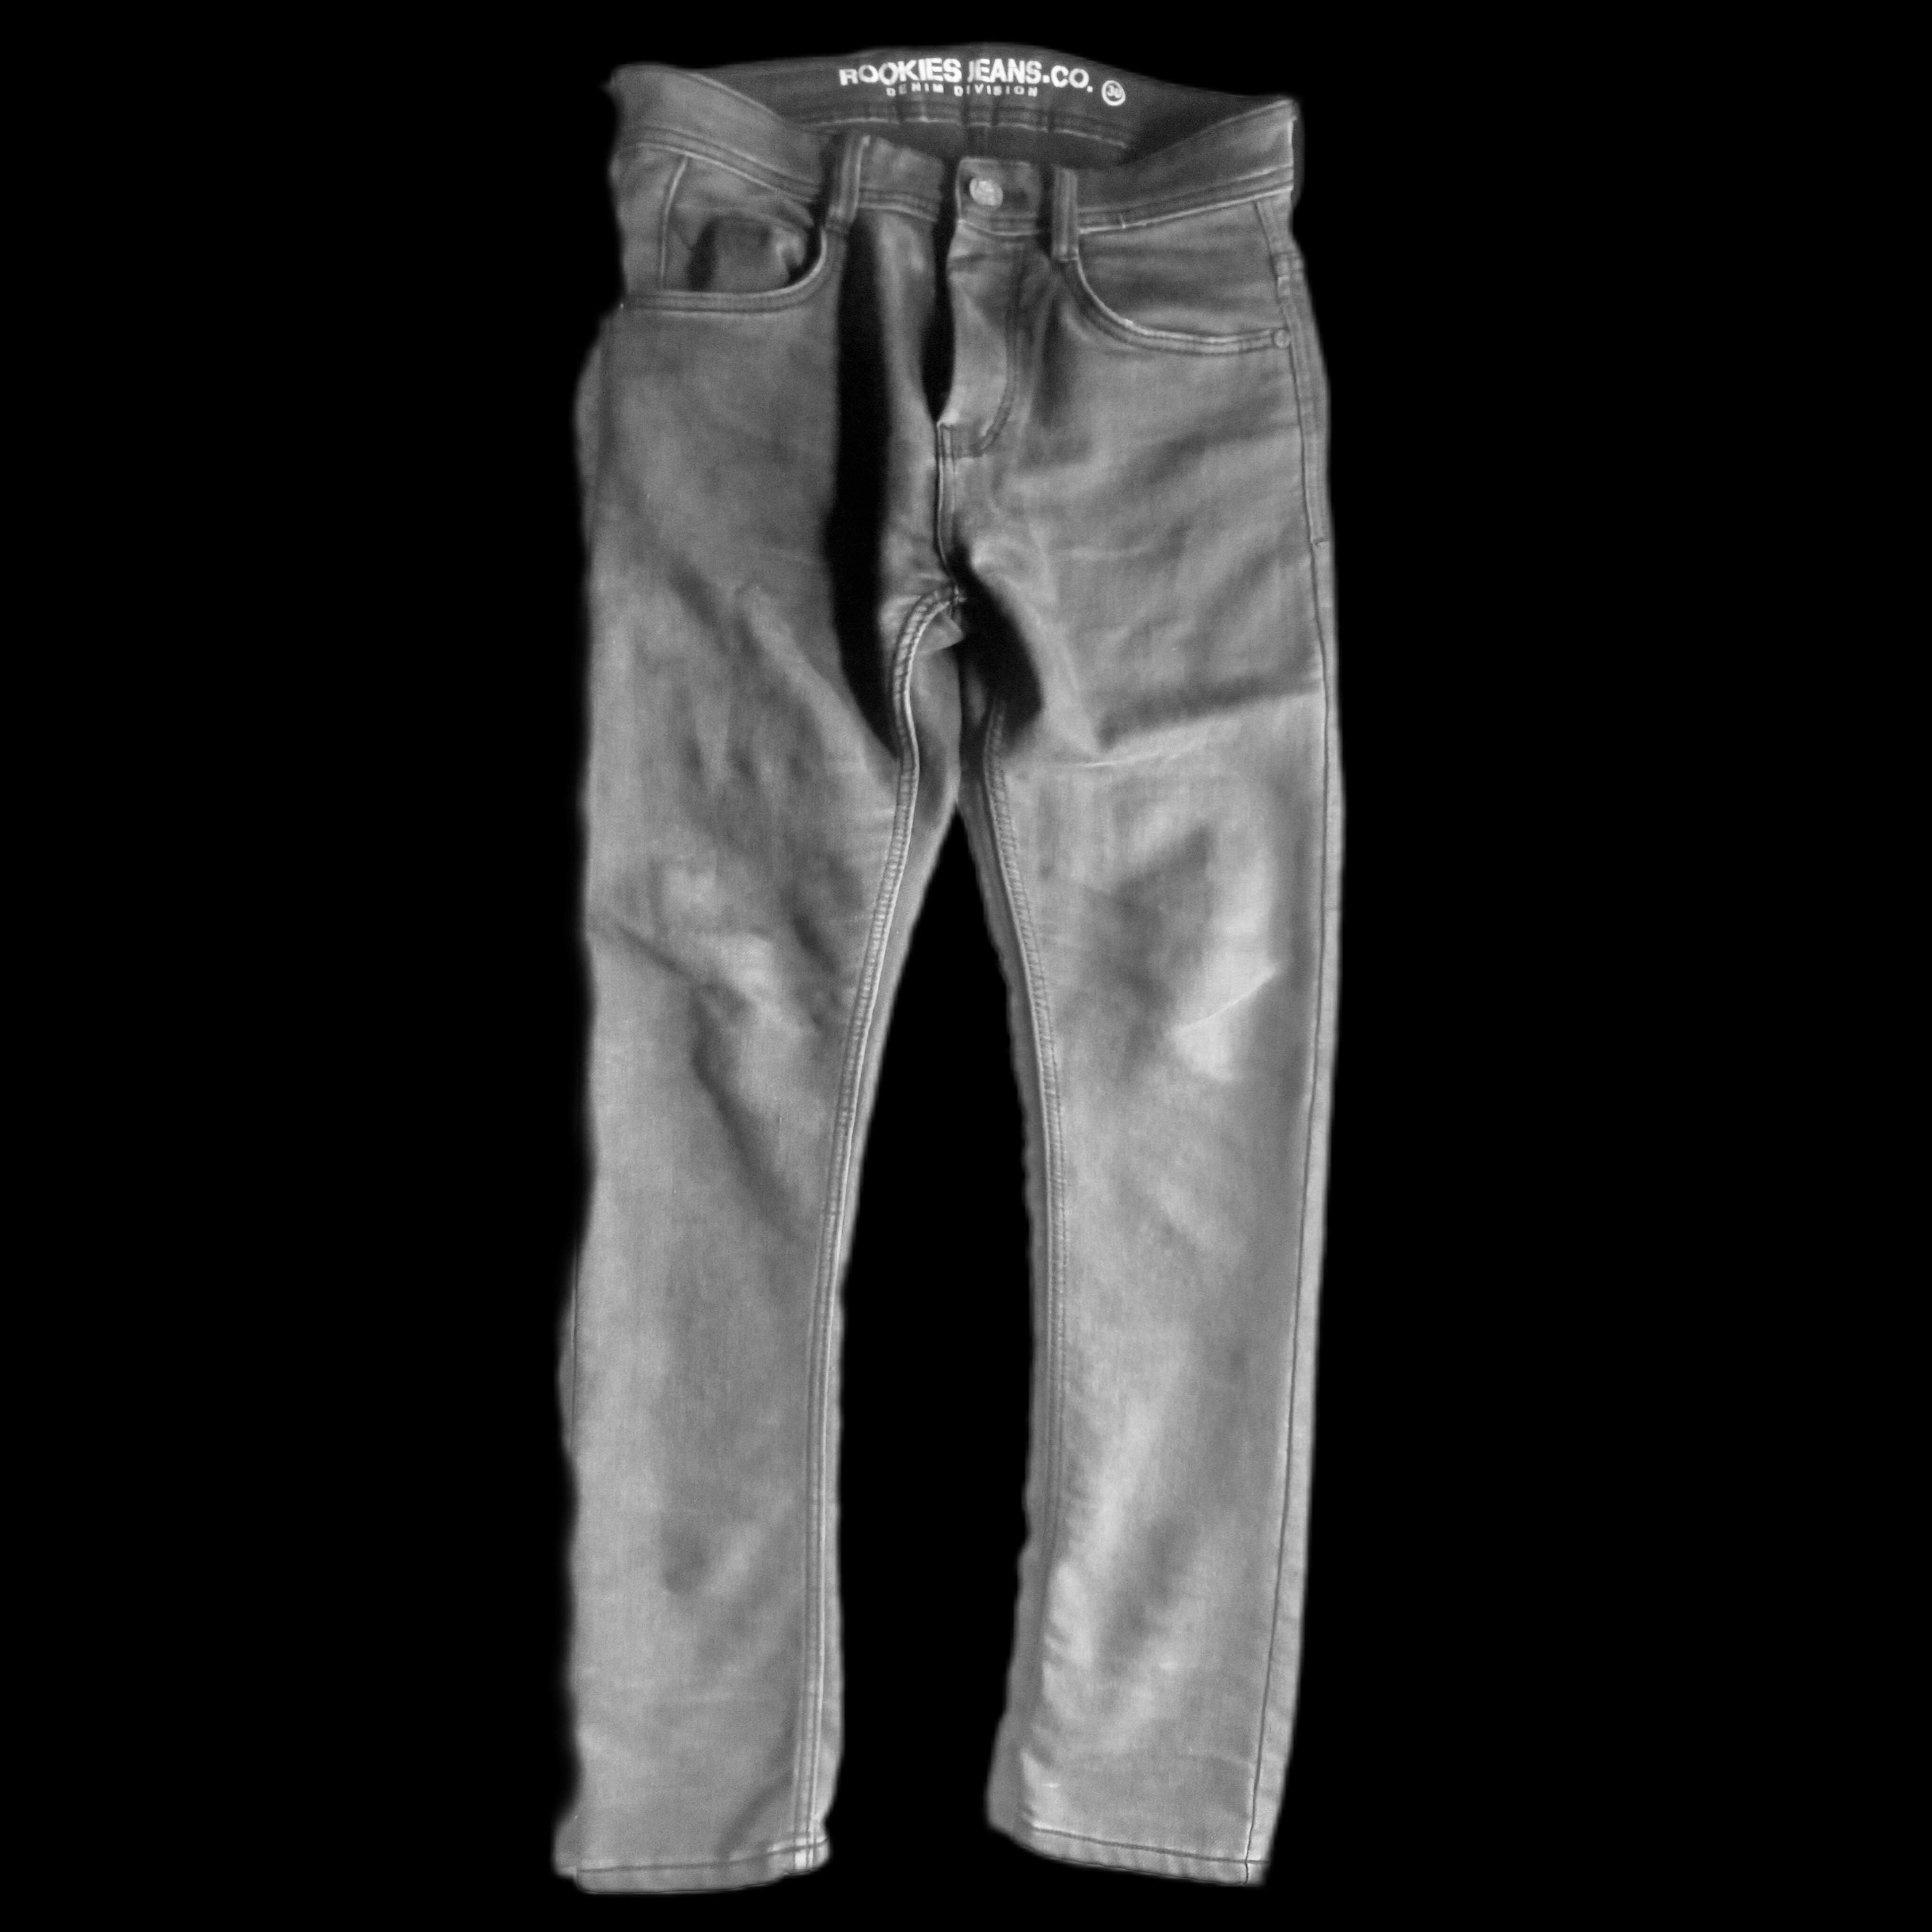

In [213]:
realWorldOne = realWorldOne.convert("L")
realWorldOne

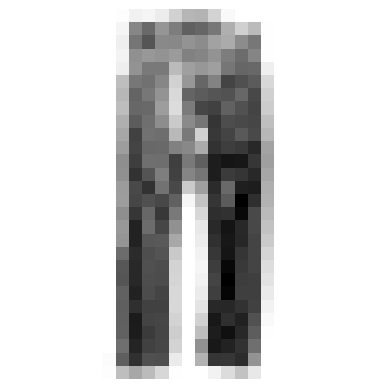

In [214]:
realWorldOne = realWorldOne.resize((28, 28))
realWorldOne = np.array(realWorldOne).astype("float32") / 255.0
displayImage(realWorldOne)

In [215]:
finalProba = finalModel.predict(np.expand_dims(realWorldOne, axis=0))
finalPredictIndex = finalProba.argmax()
class_names[finalPredictIndex]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


'Trouser'

In [216]:
finalProba.round(2)

array([[0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)